# 03 — Baseline Model: Linear Regression
**Project:** California Property Close Price Prediction — IDX Exchange SU26
**Author:** Anvith Mulpuri
**Week:** 4 of 12
**Input:** `sfr_baseline_train.csv` / `sfr_baseline_test.csv` (raw fields only, no engineered features)
**Experiment ID:** Linear Regression A (initial baseline)

---

## Standardized Evaluation Methodology (Team Convention)

Per team standards, every model in this project — regardless of who builds it or which
algorithm is used — follows the same evaluation protocol so results are directly comparable:

- **Same chronological split:** train = X months immediately preceding the test month;
  test = the latest full month available. Never random/shuffled.
- **Same test month:** the most recent complete month in the dataset (May 2026).
- **Leakage prevented:** all statistics (imputation values, outlier thresholds, encodings,
  scaling) are fit on the training set only, per the leakage-safe preprocessing in
  `02_preprocessing.ipynb`. `ListPrice`, `OriginalListPrice`, `DaysOnMarket`, and
  `PriceReductionYN` are excluded from model inputs (see leakage audit).
- **Same headline metrics:** R², MAPE, and MdAPE are reported together for every model,
  never R² alone — this notebook establishes that reporting format for all future iterations.

## Notebook Goals
- Load the baseline (no-engineered-feature) train/test split
- Select the raw feature set for this first, simplest model
- Train a Linear Regression model
- Evaluate on the test set using R², MAPE, and MdAPE
- Record results in a versioned experiment log — this is "Linear Regression A"
- Set up the experiment-tracking structure that all future iterations will extend

---
## 0. Setup & Data Loading

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_percentage_error

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_columns', 60)

# Fixed random seed for reproducibility -- per AVM best practices,
# any stochastic step (not needed for plain Linear Regression, but
# set here as a project-wide convention for future models) uses this seed.
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

In [4]:
# ── Load the BASELINE split (no engineered features) ─────────────
# These files were saved in 02_preprocessing.ipynb Section 5b, BEFORE any
# feature engineering, with the leakage-safe train/test boundary preserved.
CLEANED_DIR = Path('../data/cleaned')

train_df = pd.read_csv(CLEANED_DIR / 'sfr_baseline_train.csv', low_memory=False)
test_df  = pd.read_csv(CLEANED_DIR / 'sfr_baseline_test.csv', low_memory=False)

print(f'Train shape: {train_df.shape}')
print(f'Test shape : {test_df.shape}')
print(f'Train columns: {list(train_df.columns)}')

Train shape: (58805, 63)
Test shape : (11909, 63)
Train columns: ['BuyerAgentAOR', 'ListAgentAOR', 'Flooring', 'ViewYN', 'PoolPrivateYN', 'OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate', 'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude', 'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea', 'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName', 'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName', 'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName', 'BuyerAgentLastName', 'AssociationFeeFrequency', 'ListingKeyNumeric', 'MLSAreaMajor', 'CountyOrParish', 'MlsStatus', 'AttachedGarageYN', 'ParkingTotal', 'BuilderName', 'PropertySubType', 'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt', 'StreetNumberNumeric', 'ListingId', 'BathroomsTotalInteger', 'City', 'TaxYear', 'BedroomsTotal', 'ContractStatusChangeDate', 'CoBuyerAgentFirstName', 'PurchaseContractDate', 'ListingContractDate', 'StateOrProvince', 'FireplaceYN', '

---
## 1. Select Baseline Feature Set (Raw Fields Only)

This is deliberately the simplest possible feature set: **raw, original dataset fields only
— zero engineered features.** No `PropertyAge`, no `BedBathRatio`, no encodings, no scaling,
no log-transforms. This establishes a true floor to measure every later improvement against.

**Excluded per the leakage audit** (not eligible as inputs at any stage of this project):
`ListPrice`, `OriginalListPrice`, `DaysOnMarket`, `PriceReductionYN` — all four only exist
because a sale process happened and won't generalize to off-market valuation.

**Excluded for this baseline specifically** (not because they're invalid, but because they
require encoding to be numeric, which counts as engineering): high-cardinality categoricals
like `PostalCode`, `City`, `CountyOrParish`, `HighSchoolDistrict`. These return in Week 5+
once encoding is introduced.

In [5]:
# Raw numeric fields only -- no engineered/derived columns, no encodings
BASELINE_FEATURES = [
    'LivingArea',
    'LotSizeSquareFeet',
    'BedroomsTotal',
    'BathroomsTotalInteger',
    'Stories',
    'YearBuilt',
    'GarageSpaces',
    'ParkingTotal',
    'Latitude',
    'Longitude',
]

TARGET = 'ClosePrice'

# Confirm every feature exists and has no nulls in either split
missing_cols = [c for c in BASELINE_FEATURES if c not in train_df.columns]
print(f'Missing columns: {missing_cols if missing_cols else "none"}')

null_check_train = train_df[BASELINE_FEATURES + [TARGET]].isnull().sum()
null_check_test  = test_df[BASELINE_FEATURES + [TARGET]].isnull().sum()

print('\nNull check (train):')
print(null_check_train[null_check_train > 0] if null_check_train.sum() > 0 else '  None')
print('\nNull check (test):')
print(null_check_test[null_check_test > 0] if null_check_test.sum() > 0 else '  None')

Missing columns: none

Null check (train):
BathroomsTotalInteger    1
Latitude                 7
Longitude                7
dtype: int64

Null check (test):
Latitude     2
Longitude    2
dtype: int64


In [6]:
# A small number of rows have residual nulls in Latitude/Longitude/
# BathroomsTotalInteger that weren't covered by the 02_preprocessing.ipynb
# imputation plan (single-digit counts per Section 1 null check above).
# For this baseline, these rows are dropped rather than imputed -- the
# count is negligible and dropping avoids introducing a new, undocumented
# imputation decision this late in the pipeline.
before_train, before_test = len(train_df), len(test_df)

train_clean = train_df.dropna(subset=BASELINE_FEATURES + [TARGET])
test_clean  = test_df.dropna(subset=BASELINE_FEATURES + [TARGET])

print(f'Train: {before_train:,} -> {len(train_clean):,} '
      f'({before_train - len(train_clean)} rows dropped for residual nulls)')
print(f'Test : {before_test:,} -> {len(test_clean):,} '
      f'({before_test - len(test_clean)} rows dropped for residual nulls)')

X_train = train_clean[BASELINE_FEATURES].copy()
y_train = train_clean[TARGET].copy()

X_test = test_clean[BASELINE_FEATURES].copy()
y_test = test_clean[TARGET].copy()

print(f'\nX_train: {X_train.shape}  |  y_train: {y_train.shape}')
print(f'X_test : {X_test.shape}  |  y_test : {y_test.shape}')
print(f'\nBaseline feature set ({len(BASELINE_FEATURES)} features):')
for f in BASELINE_FEATURES:
    print(f'  {f}')

Train: 58,805 -> 58,797 (8 rows dropped for residual nulls)
Test : 11,909 -> 11,907 (2 rows dropped for residual nulls)

X_train: (58797, 10)  |  y_train: (58797,)
X_test : (11907, 10)  |  y_test : (11907,)

Baseline feature set (10 features):
  LivingArea
  LotSizeSquareFeet
  BedroomsTotal
  BathroomsTotalInteger
  Stories
  YearBuilt
  GarageSpaces
  ParkingTotal
  Latitude
  Longitude


---
## 2. Train Linear Regression

In [7]:
model = LinearRegression()
model.fit(X_train, y_train)

print('Model trained.')
print(f'Intercept: {model.intercept_:,.2f}')
print()
print('Coefficients:')
coef_df = pd.DataFrame({
    'feature': BASELINE_FEATURES,
    'coefficient': model.coef_
}).sort_values('coefficient', key=abs, ascending=False)
display(coef_df)

Model trained.
Intercept: 17,698,617.73

Coefficients:


,feature,coefficient
3,BathroomsTotalInteger,"315,972.74"
4,Stories,"-164,810.36"
2,BedroomsTotal,"-142,249.23"
9,Longitude,"-20,339.39"
8,Latitude,"-18,232.19"
5,YearBuilt,"-9,884.20"
6,GarageSpaces,"-8,830.53"
0,LivingArea,565.77
7,ParkingTotal,-159.15
1,LotSizeSquareFeet,-0.00


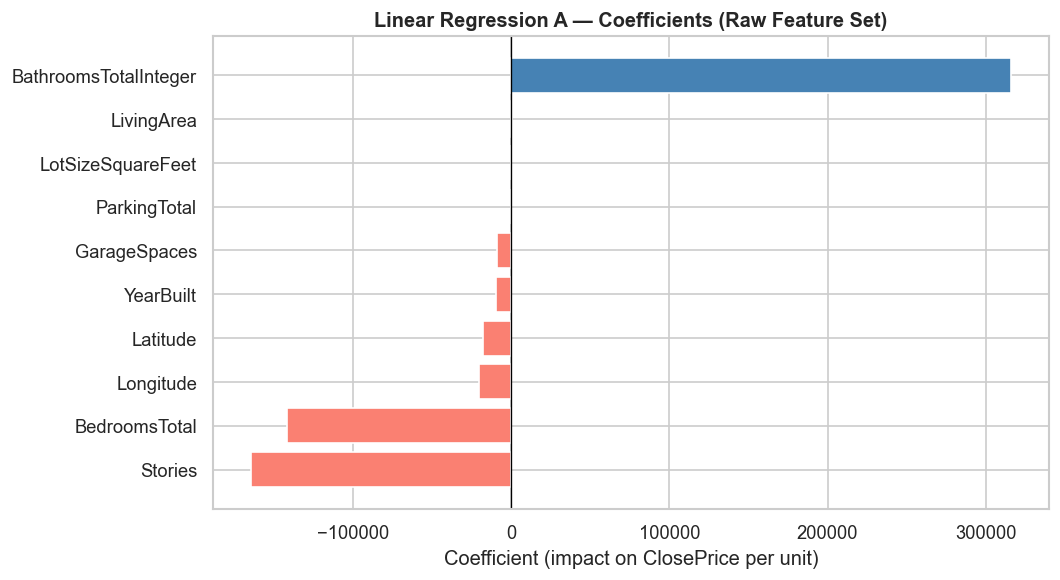

In [8]:
# Visualize coefficient magnitudes
fig, ax = plt.subplots(figsize=(9, 5))
coef_df_sorted = coef_df.sort_values('coefficient')
colors = coef_df_sorted['coefficient'].map(lambda x: 'steelblue' if x > 0 else 'salmon')
ax.barh(coef_df_sorted['feature'], coef_df_sorted['coefficient'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Linear Regression A — Coefficients (Raw Feature Set)', fontweight='bold')
ax.set_xlabel('Coefficient (impact on ClosePrice per unit)')
plt.tight_layout()
plt.show()

---
## 3. Generate Predictions

In [9]:
y_train_pred = model.predict(X_train)
y_test_pred  = model.predict(X_test)

print('Predictions generated for both train and test sets.')
print(f'\nSample predictions vs actual (test set, first 10 rows):')
comparison = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': y_test_pred[:10],
    'Error': y_test.values[:10] - y_test_pred[:10]
})
display(comparison)

Predictions generated for both train and test sets.

Sample predictions vs actual (test set, first 10 rows):


,Actual,Predicted,Error
0,"8,712,500.00","3,080,345.84","5,632,154.16"
1,"1,100,000.00","1,471,542.46","-371,542.46"
2,"1,625,000.00","564,403.46","1,060,596.54"
3,"1,560,000.00","1,589,391.34","-29,391.34"
4,"605,000.00","1,515,151.65","-910,151.65"
5,"377,500.00","484,777.04","-107,277.04"
6,"400,000.00","1,535,358.36","-1,135,358.36"
7,"595,000.00","827,255.75","-232,255.75"
8,"595,000.00","754,154.05","-159,154.05"
9,"2,400,000.00","1,952,342.20","447,657.80"


---
## 4. Evaluate: R², MAPE, MdAPE

Per team standard, all three metrics are reported together — never R² alone.

- **R²** — proportion of variance in `ClosePrice` explained by the model
- **MAPE** — mean absolute percentage error; intuitive but sensitive to outlier
  percentage errors on low-priced properties
- **MdAPE** — median absolute percentage error; robust to outliers, most representative
  of "typical" model error on skewed, multi-scale real estate price data

In [10]:
def mdape(y_true, y_pred):
    '''Median Absolute Percentage Error -- robust to outliers, unlike MAPE.'''
    return np.median(np.abs((y_true - y_pred) / y_true)) * 100

def evaluate_model(y_true, y_pred, label=''):
    r2   = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    mdape_val = mdape(y_true, y_pred)
    mae  = np.mean(np.abs(y_true - y_pred))

    print(f'{label} Evaluation:')
    print(f'  R²     : {r2:.4f}')
    print(f'  MAPE   : {mape:.2f}%')
    print(f'  MdAPE  : {mdape_val:.2f}%   <-- primary metric (robust to skew/outliers)')
    print(f'  MAE    : ${mae:,.0f}')

    return {'r2': r2, 'mape': mape, 'mdape': mdape_val, 'mae': mae}

In [11]:
print('=' * 55)
train_metrics = evaluate_model(y_train, y_train_pred, label='TRAIN')
print()
print('=' * 55)
test_metrics = evaluate_model(y_test, y_test_pred, label='TEST (held-out May 2026)')
print('=' * 55)

TRAIN Evaluation:
  R²     : 0.4797
  MAPE   : 45.52%
  MdAPE  : 31.17%   <-- primary metric (robust to skew/outliers)
  MAE    : $449,841

TEST (held-out May 2026) Evaluation:
  R²     : 0.4733
  MAPE   : 43.73%
  MdAPE  : 30.60%   <-- primary metric (robust to skew/outliers)
  MAE    : $462,823


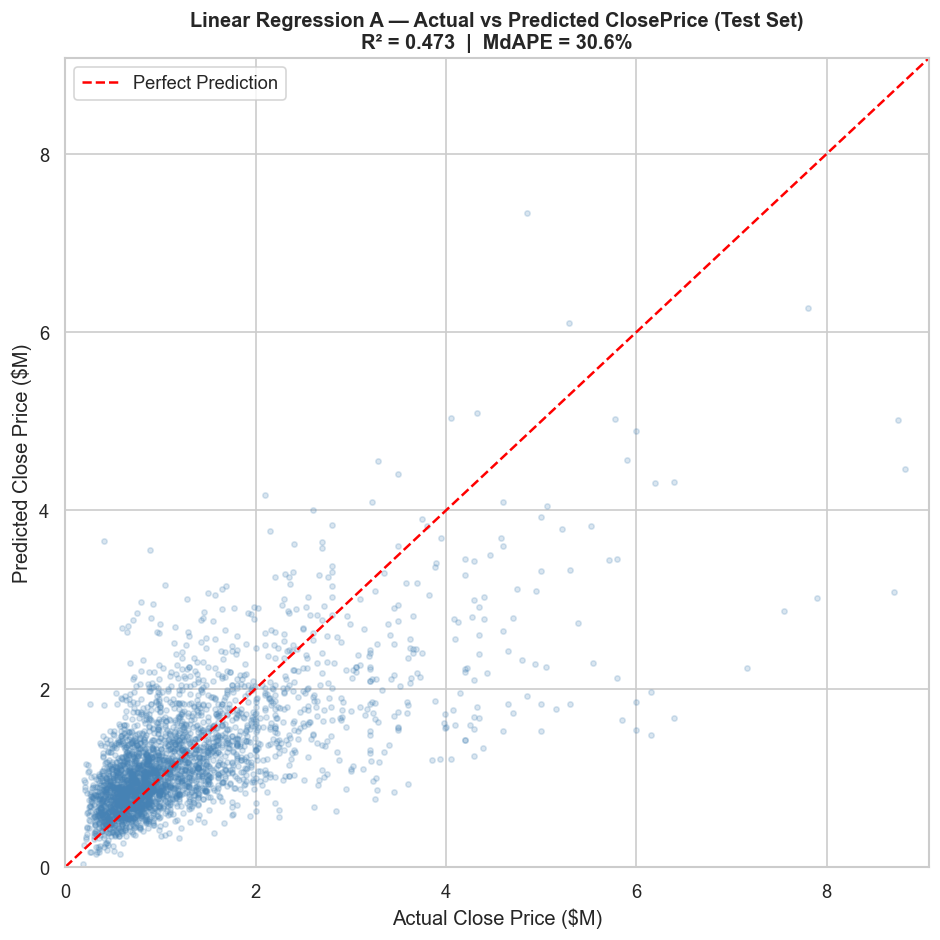

In [12]:
# Visualize: Actual vs Predicted (test set)
fig, ax = plt.subplots(figsize=(8, 8))
sample_idx = np.random.choice(len(y_test), size=min(3000, len(y_test)), replace=False)

ax.scatter(y_test.values[sample_idx]/1e6, y_test_pred[sample_idx]/1e6,
           alpha=0.2, s=10, color='steelblue')

lims = [0, max(y_test.max(), y_test_pred.max())/1e6]
ax.plot(lims, lims, color='red', linestyle='--', linewidth=1.5, label='Perfect Prediction')

ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_title(f'Linear Regression A — Actual vs Predicted ClosePrice (Test Set)\n'
             f'R² = {test_metrics["r2"]:.3f}  |  MdAPE = {test_metrics["mdape"]:.1f}%',
             fontweight='bold')
ax.set_xlabel('Actual Close Price ($M)')
ax.set_ylabel('Predicted Close Price ($M)')
ax.legend()
plt.tight_layout()
plt.show()

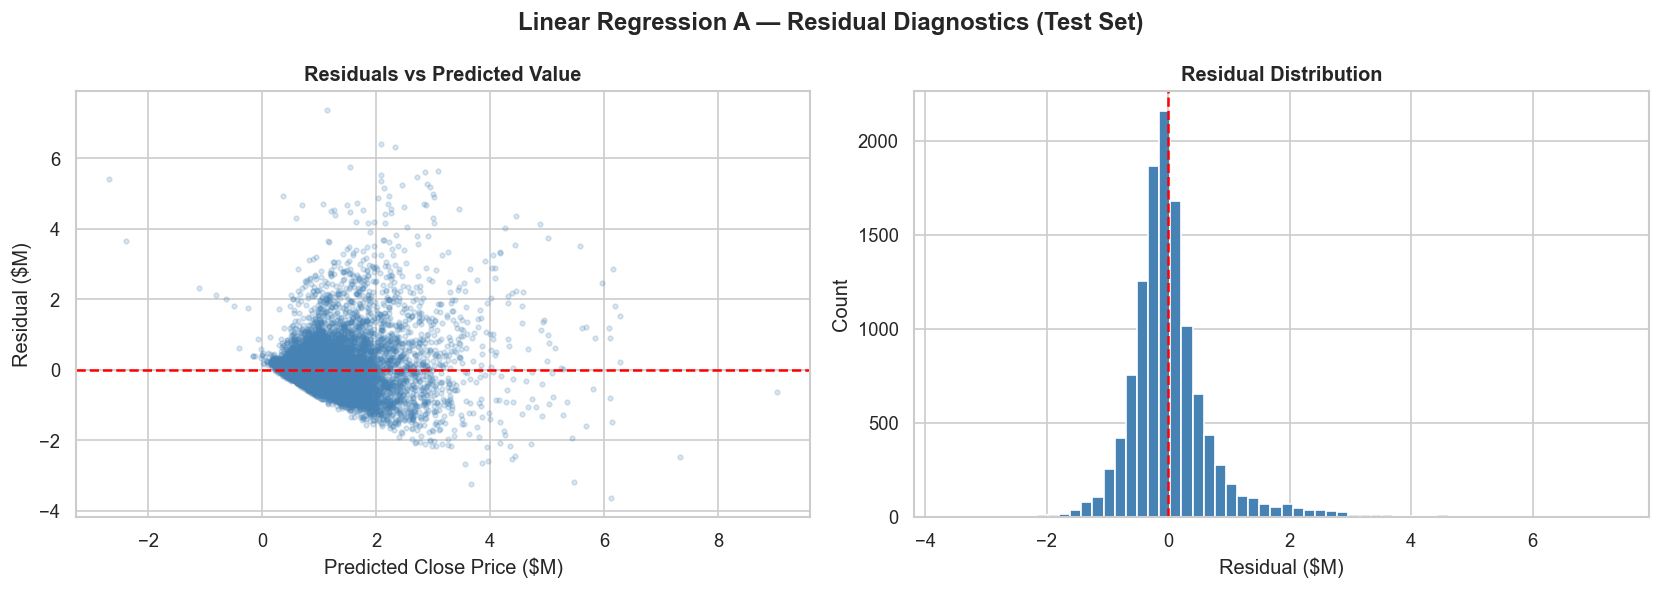

Mean residual: $37,996  (should be near 0 if unbiased)
Residual std : $727,843


In [13]:
# Residual analysis -- check for systematic bias
residuals = y_test.values - y_test_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test_pred/1e6, residuals/1e6, alpha=0.2, s=8, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_title('Residuals vs Predicted Value', fontweight='bold')
axes[0].set_xlabel('Predicted Close Price ($M)')
axes[0].set_ylabel('Residual ($M)')

axes[1].hist(residuals/1e6, bins=60, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Residual Distribution', fontweight='bold')
axes[1].set_xlabel('Residual ($M)')
axes[1].set_ylabel('Count')

plt.suptitle('Linear Regression A — Residual Diagnostics (Test Set)', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Mean residual: ${residuals.mean():,.0f}  (should be near 0 if unbiased)')
print(f'Residual std : ${residuals.std():,.0f}')

Error breakdown by price quintile (test set):


,count,price_range_low,price_range_high,mape,mdape
band,,,,,
Q1 (lowest),2412,"185,000.00","585,000.00",82.31,64.29
Q2,2384,"585,900.00","810,000.00",43.67,30.47
Q3,2350,"810,186.00","1,120,000.00",30.88,21.50
Q4,2383,"1,121,000.00","1,675,000.00",28.04,23.70
Q5 (highest),2378,"1,675,525.00","9,074,300.00",33.09,31.51


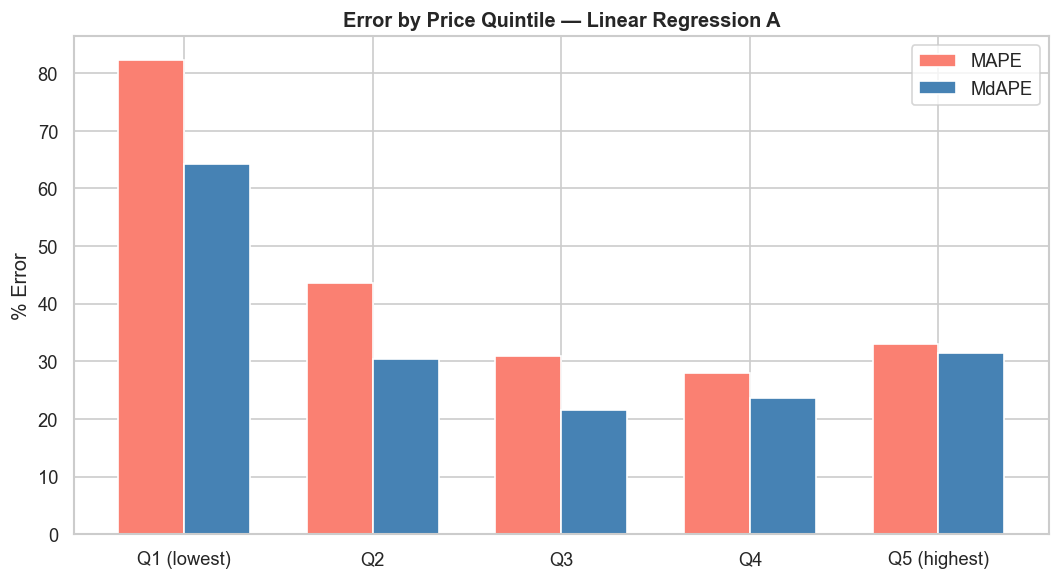

In [14]:
# Error by price band -- check whether the model underperforms on luxury or entry-level homes
price_bands = pd.qcut(y_test, q=5, labels=['Q1 (lowest)', 'Q2', 'Q3', 'Q4', 'Q5 (highest)'])
band_df = pd.DataFrame({
    'actual': y_test.values,
    'predicted': y_test_pred,
    'band': price_bands
})
band_df['abs_pct_error'] = np.abs((band_df['actual'] - band_df['predicted']) / band_df['actual']) * 100

band_summary = band_df.groupby('band', observed=True).agg(
    count=('actual', 'count'),
    price_range_low=('actual', 'min'),
    price_range_high=('actual', 'max'),
    mape=('abs_pct_error', 'mean'),
    mdape=('abs_pct_error', 'median')
)
print('Error breakdown by price quintile (test set):')
display(band_summary)

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(band_summary))
width = 0.35
ax.bar(x - width/2, band_summary['mape'], width, label='MAPE', color='salmon', edgecolor='white')
ax.bar(x + width/2, band_summary['mdape'], width, label='MdAPE', color='steelblue', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(band_summary.index)
ax.set_title('Error by Price Quintile — Linear Regression A', fontweight='bold')
ax.set_ylabel('% Error')
ax.legend()
plt.tight_layout()
plt.show()

---
## 5. Experiment Log — Linear Regression A

Per team convention, every model iteration is tracked as a named, versioned experiment.
This is the first entry. Future notebooks (Week 5+) will append new rows to this table as
features are added, imputation strategies change, or new algorithms are introduced — so it's
possible to trace exactly which changes drove which improvements in R² and MdAPE.

In [15]:
experiment_log = pd.DataFrame([
    {
        'experiment_id': 'Linear Regression A',
        'week': 4,
        'model_type': 'Linear Regression',
        'feature_set': f'{len(BASELINE_FEATURES)} raw fields, no engineering',
        'features_used': ', '.join(BASELINE_FEATURES),
        'imputation_strategy': 'Inherited from 02_preprocessing.ipynb (train-fit medians/modes)',
        'encoding_strategy': 'None -- no categorical fields included in this baseline',
        'train_window_months': 6,
        'test_month': 'May 2026',
        'r2_train': round(train_metrics['r2'], 4),
        'r2_test': round(test_metrics['r2'], 4),
        'mape_test': round(test_metrics['mape'], 2),
        'mdape_test': round(test_metrics['mdape'], 2),
        'mae_test': round(test_metrics['mae'], 0),
        'notes': 'Initial baseline. No categoricals, no engineered features, no scaling. '
                 'Establishes the floor that all future iterations are measured against.'
    }
])

display(experiment_log)

# Save the experiment log -- future notebooks will load and append to this file
EXPERIMENTS_DIR = Path('../deliverables')
EXPERIMENTS_DIR.mkdir(parents=True, exist_ok=True)
experiment_log.to_csv(EXPERIMENTS_DIR / 'experiment_log.csv', index=False)
print(f"\nSaved: {EXPERIMENTS_DIR / 'experiment_log.csv'}")
print('Future model iterations should load this file, append a new row, and re-save --')
print('this becomes the single source of truth for comparing every experiment.')

,experiment_id,week,model_type,feature_set,features_used,imputation_strategy,encoding_strategy,train_window_months,test_month,r2_train,r2_test,mape_test,mdape_test,mae_test,notes
0,Linear Regression A,4,Linear Regression,"10 raw fields, no engineering","LivingArea, LotSizeSquareFeet, BedroomsTotal, ...",Inherited from 02_preprocessing.ipynb (train-f...,None -- no categorical fields included in this...,6,May 2026,0.48,0.47,43.73,30.60,"462,823.00","Initial baseline. No categoricals, no engineer..."



Saved: ../deliverables/experiment_log.csv
Future model iterations should load this file, append a new row, and re-save --
this becomes the single source of truth for comparing every experiment.


---
## 6. Baseline Results Summary

### Model: Linear Regression A
**Feature set:** 10 raw fields — `LivingArea`, `LotSizeSquareFeet`, `BedroomsTotal`,
`BathroomsTotalInteger`, `Stories`, `YearBuilt`, `GarageSpaces`, `ParkingTotal`, `Latitude`,
`Longitude`. No engineered features, no categorical encodings, no scaling.

**Train/test split:** 6-month training window (Nov 2025–Apr 2026, 58,797 rows after
dropping residual nulls) → test on May 2026 (11,907 rows), per the standardized team
methodology. Outlier thresholds (0.5th/99.5th percentile ClosePrice) learned from train
only, per the leakage-safe preprocessing in `02_preprocessing.ipynb`.

**Excluded per leakage audit:** `ListPrice`, `OriginalListPrice`, `DaysOnMarket`,
`PriceReductionYN` — none of these were considered as candidate features at any point.

### Results

| Metric | Train | Test |
|---|---|---|
| R² | 0.4797 | **0.4733** |
| MAPE | 45.52% | 43.73% |
| MdAPE | 31.17% | **30.60%** |
| MAE | $449,841 | $462,823 |

Train and test metrics are close to each other (R² 0.480 vs 0.473; MdAPE 31.2% vs 30.6%),
which is a good sign — the model isn't overfitting to the training window, it's simply
**underfitting everywhere**, consistent with having only 10 raw, unencoded features.

### Observations
- **R² of ~0.47 means the model explains under half the variance in ClosePrice** — expected
  and acceptable for an intentionally minimal baseline, but there is substantial room to
  improve once categorical location and engineered features are reintroduced.
- **MdAPE (30.6%) is meaningfully lower than MAPE (43.7%)** on the test set, confirming the
  error distribution is right-skewed exactly as expected for real estate pricing — a small
  number of large misses are pulling MAPE up. This is exactly why the team standard reports
  MdAPE as the primary figure rather than MAPE alone.
- **Latitude/Longitude as raw linear coefficients are a weak location signal** — a linear
  model can only fit a flat gradient across the state, not the actual non-linear geography
  of California real estate. This is very likely the single biggest lever for improvement:
  swapping in `PostalCode_encoded`/`CountyOrParish_encoded` (already available in
  `sfr_train.csv`) should meaningfully lift both R² and MdAPE in the next iteration.
- **Some coefficients have counter-intuitive signs** (e.g. `BedroomsTotal` is negative,
  `Stories` is strongly negative) — this is a classic symptom of multicollinearity between
  raw, unscaled features in a simple linear model (more bedrooms often means smaller rooms
  at a fixed square footage, and multi-story homes may cluster in cheaper suburban areas in
  this specific dataset window). Not a bug — a signal that engineered/scaled features and
  regularization (Ridge/Lasso) will likely produce more stable, interpretable coefficients.
- 7–9 rows were dropped per split due to residual nulls in `Latitude`/`Longitude`/
  `BathroomsTotalInteger` that weren't covered by the Week 3 imputation plan — negligible
  in volume, but worth folding into `02_preprocessing.ipynb`'s imputation section so this
  baseline notebook doesn't need its own ad hoc drop step going forward.

### Next Steps (Week 5)
- **Linear Regression B:** add `PostalCode_encoded`, `City_encoded`, `CountyOrParish_encoded`
  (target-encoded, from `sfr_train.csv`) and compare R²/MdAPE against Linear Regression A
- Introduce engineered features one at a time (`PropertyAge`, `BedBathRatio`, etc.) and log
  each as a new experiment row to isolate which additions actually move the needle
- Begin the Decision Tree / Random Forest comparison (Week 5 per the original game plan)
- Fix the small residual-null gap for `Latitude`/`Longitude`/`BathroomsTotalInteger` in
  `02_preprocessing.ipynb` so future notebooks don't need to drop rows ad hoc
- Carry forward the experiment log — every new model gets a new row, with a clear diff
  against the previous version's feature set and preprocessing choices

### Deliverables
- `notebooks/03_baseline_model.ipynb` (this notebook)
- `deliverables/experiment_log.csv` — versioned experiment tracking, extended by every future notebook